This is to conduct study of data analysis before modeling

In [2]:
#
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

#import os
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

import yfinance as yf

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Data source from yfinance as below
#   tentatively retreive 3 years stock data

company = "0700.HK"
df_HKstock = yf.download(company, start="2023-01-01", end="2026-01-01",
                    auto_adjust=True ).droplevel('Ticker', axis=1)
df_HKstock

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,316.281708,316.831432,301.255591,306.019968,31541576
2023-01-04,330.758118,330.758118,319.763392,320.679609,39409103
2023-01-05,335.513885,349.405226,331.462269,345.353580,40803927
2023-01-06,337.057373,346.704121,334.549213,341.109019,27092487
2023-01-09,349.212280,349.598144,339.179668,342.459557,28323733
...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
2025-12-24,595.561157,595.561157,595.561157,595.561157,0
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650


In [5]:
# Save copy to CSV
df_HKstock.to_csv('0700.HK260101.csv')

In [6]:
#
df_source = pd.read_csv("0700.HK260101.csv")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,316.281708,316.831432,301.255591,306.019968,31541576
1,2023-01-04,330.758118,330.758118,319.763392,320.679609,39409103
2,2023-01-05,335.513885,349.405226,331.462269,345.353580,40803927
3,2023-01-06,337.057373,346.704121,334.549213,341.109019,27092487
4,2023-01-09,349.212280,349.598144,339.179668,342.459557,28323733
...,...,...,...,...,...,...
730,2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
731,2025-12-24,595.561157,595.561157,595.561157,595.561157,0
732,2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650
733,2025-12-30,593.089966,594.078449,587.159066,591.607241,13582535


In [7]:
# Set Date
df_source["Date"] = pd.to_datetime(df_source["Date"], format="%Y-%m-%d")
df_source

,Date,Close,High,Low,Open,Volume
0,2023-01-03,316.281708,316.831432,301.255591,306.019968,31541576
1,2023-01-04,330.758118,330.758118,319.763392,320.679609,39409103
2,2023-01-05,335.513885,349.405226,331.462269,345.353580,40803927
3,2023-01-06,337.057373,346.704121,334.549213,341.109019,27092487
4,2023-01-09,349.212280,349.598144,339.179668,342.459557,28323733
...,...,...,...,...,...,...
730,2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
731,2025-12-24,595.561157,595.561157,595.561157,595.561157,0
732,2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650
733,2025-12-30,593.089966,594.078449,587.159066,591.607241,13582535


In [8]:
df_source.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    735 non-null    datetime64[ns]
 1   Close   735 non-null    float64       
 2   High    735 non-null    float64       
 3   Low     735 non-null    float64       
 4   Open    735 non-null    float64       
 5   Volume  735 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 34.6 KB


In [9]:
# Set Date as index - time series data
df_source = df_source.set_index('Date', ) 
df_source.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 735 entries, 2023-01-03 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   735 non-null    float64
 1   High    735 non-null    float64
 2   Low     735 non-null    float64
 3   Open    735 non-null    float64
 4   Volume  735 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 34.5 KB


In [10]:
df = df_source
df

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,316.281708,316.831432,301.255591,306.019968,31541576
2023-01-04,330.758118,330.758118,319.763392,320.679609,39409103
2023-01-05,335.513885,349.405226,331.462269,345.353580,40803927
2023-01-06,337.057373,346.704121,334.549213,341.109019,27092487
2023-01-09,349.212280,349.598144,339.179668,342.459557,28323733
...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
2025-12-24,595.561157,595.561157,595.561157,595.561157,0
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650


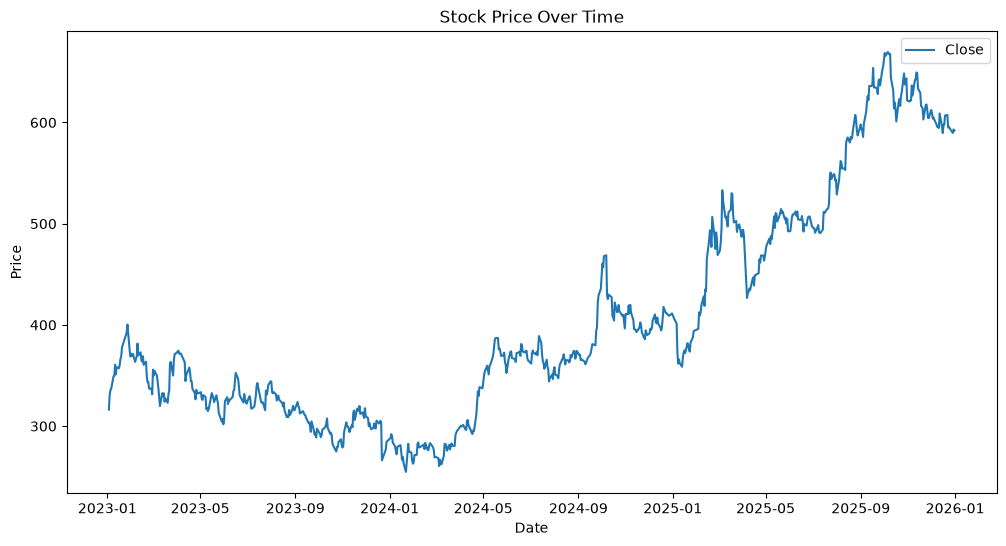

In [11]:
# To visual data 
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label='Close')
plt.title("Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

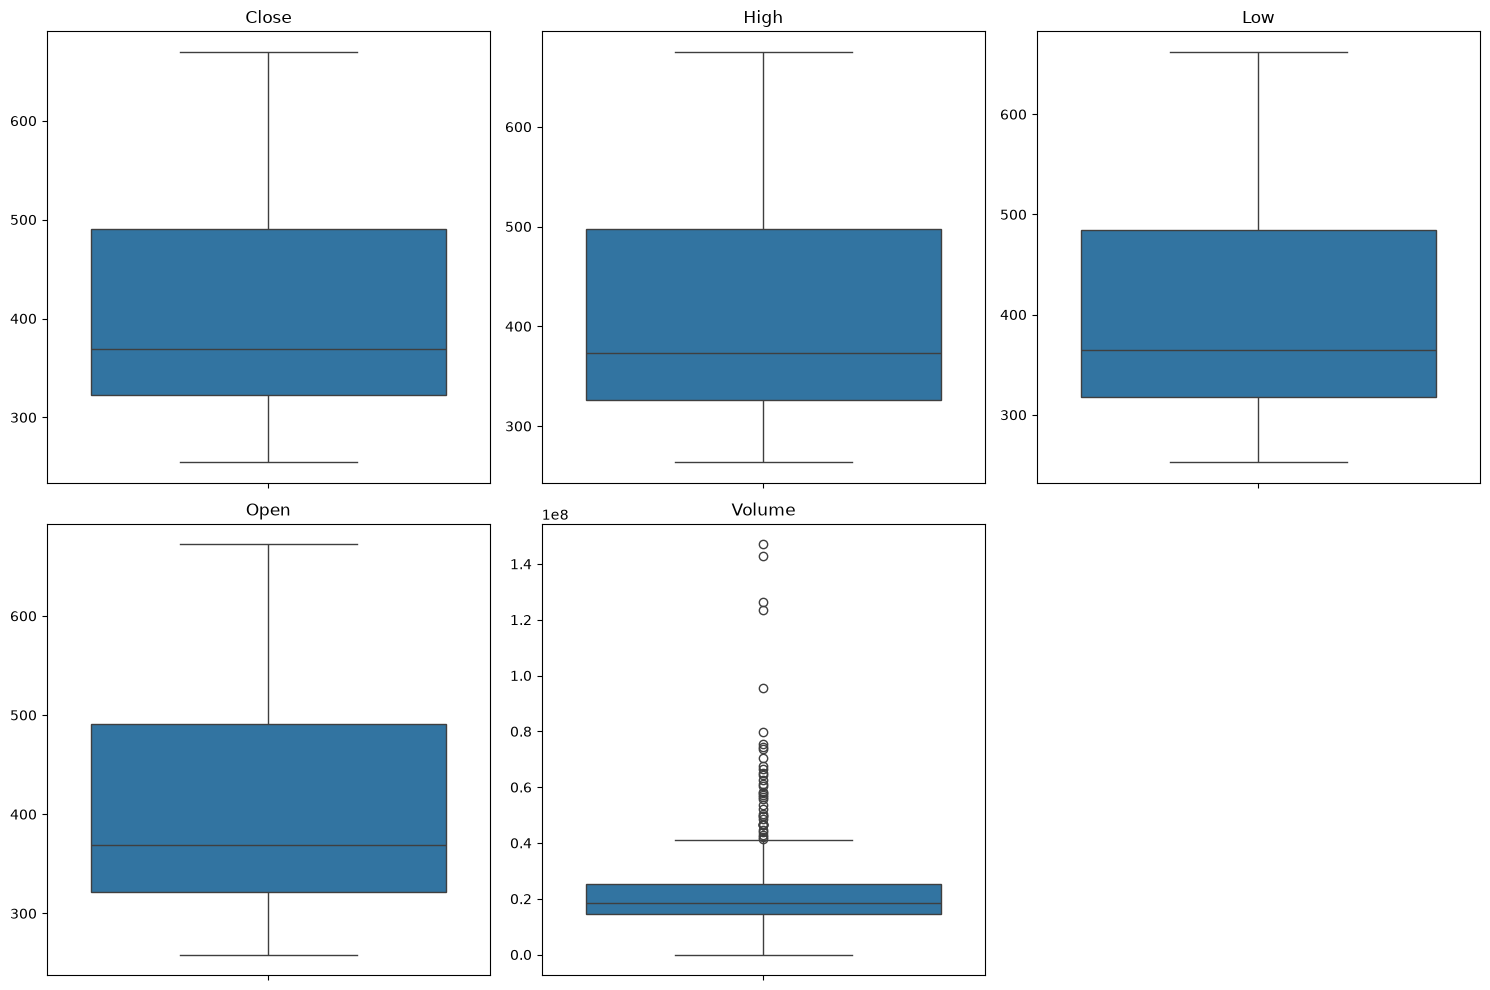

In [12]:
# To study data outliers and variations

#import math
#import matplotlib.pyplot as plt
#import seaborn as sns

num_cols = 3
num_features = len(df.columns)
num_rows = math.ceil(num_features / num_cols)

fig = plt.figure(figsize=(15, num_rows * 5))

for i, x in enumerate(df.columns, start=1):
    plt.subplot(num_rows, num_cols, i)
    ax = sns.boxplot(df[x])
    ax.set(xlabel=None)
    plt.title(str(x), loc='center')
    plt.xlabel(None)
    plt.ylabel(None)

plt.tight_layout()
plt.show()

Box plots apply to identify outliers; may identify anomalous trading days or incorrect data points

In [13]:
# Data pre-processing
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [14]:
# This is preserve as for handling missing values, if applicable
df.bfill()

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,316.281708,316.831432,301.255591,306.019968,31541576
2023-01-04,330.758118,330.758118,319.763392,320.679609,39409103
2023-01-05,335.513885,349.405226,331.462269,345.353580,40803927
2023-01-06,337.057373,346.704121,334.549213,341.109019,27092487
2023-01-09,349.212280,349.598144,339.179668,342.459557,28323733
...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392
2025-12-24,595.561157,595.561157,595.561157,595.561157,0
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650


In [15]:
# Calculate moving averages and daily returns

df['20-day MA'] = df['Close'].rolling(window=20).mean()
df['50-day MA'] = df['Close'].rolling(window=50).mean()
df['Daily Return'] = df['Close'].pct_change()

In [16]:
# To check NaN
df[df.isna().values==True].drop_duplicates()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-01-03,316.281708,316.831432,301.255591,306.019968,31541576,NaN,NaN,NaN
2023-01-04,330.758118,330.758118,319.763392,320.679609,39409103,NaN,NaN,0.045771
2023-01-05,335.513885,349.405226,331.462269,345.353580,40803927,NaN,NaN,0.014378
2023-01-06,337.057373,346.704121,334.549213,341.109019,27092487,NaN,NaN,0.004600
2023-01-09,349.212280,349.598144,339.179668,342.459557,28323733,NaN,NaN,0.036062
2023-01-10,349.598145,352.878033,344.388906,352.106305,19854116,NaN,NaN,0.001105
2023-01-11,360.595459,365.418833,353.649818,356.736759,35722217,NaN,NaN,0.031457
2023-01-12,351.141632,366.190565,343.810098,365.611754,40547528,NaN,NaN,-0.026217
2023-01-13,358.280243,359.244918,343.617202,351.720466,20970696,NaN,NaN,0.020330


In [17]:
df = df.dropna()   # Drop all NaN
df

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
Date,,,,,,,,
2023-03-16,324.130737,332.812811,322.008441,328.375301,23728825,341.234425,354.262043,-0.024957
2023-03-17,327.410614,334.356284,327.410614,328.761153,29033159,339.575183,354.484621,0.010119
2023-03-20,322.973114,327.410624,319.307362,325.095410,20437066,337.539719,354.328921,-0.013553
2023-03-21,331.462250,334.742138,318.728531,322.973094,21276362,336.661864,354.247888,0.026284
2023-03-22,334.935089,341.109002,333.970414,334.742142,19654793,336.237405,354.205443,0.010477
...,...,...,...,...,...,...,...,...
2025-12-23,595.066895,607.422935,594.572653,606.434451,15623392,601.986298,616.210574,-0.020342
2025-12-24,595.561157,595.561157,595.561157,595.561157,0,601.146088,615.844835,0.000831
2025-12-29,589.630249,603.963256,589.136007,599.020840,18502650,600.404724,615.241860,-0.009959


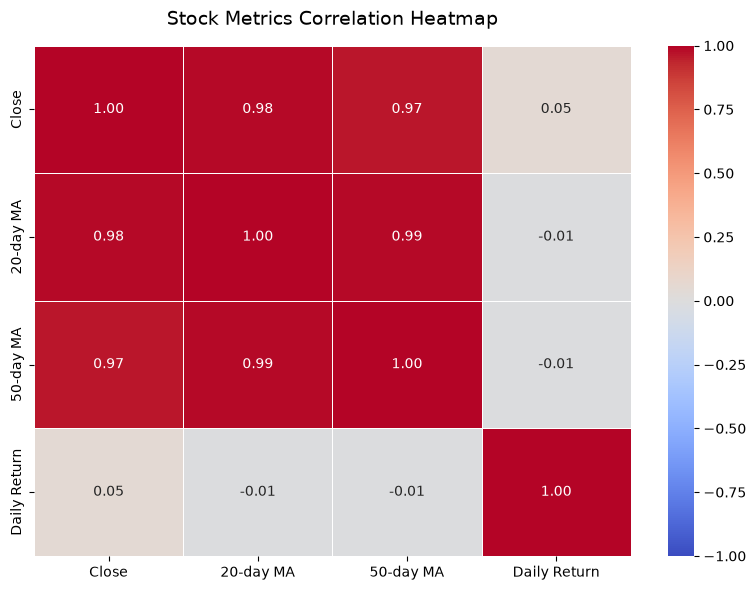

In [25]:
#import matplotlib.pyplot as plt
#import seaborn as sns

#
correlation_matrix = df["Close", "20-day MA", "50-day MA", "Daily Return"].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,       # Shows the correlation coefficients in the squares 
    cmap="coolwarm",  # Diverging colour palette (blue = negative, red = positive)
    vmin=-1,
    vmax=1,           # Sets the limits of the colour bar (-1 to 1)
    center=0,         # Centers the colour scale at 0 (neutral)
    fmt=".2f",        # Rounds numbers to 2 decimal places
    linewidths=0.5,   # Adds lines between the squares
)

#
plt.title("Stock Metrics Correlation Heatmap", fontsize=14, pad=15)
plt.tight_layout()
plt.show()


With 20-day MA & 50-day MA figures are close to 1 and 20-day MA is higher than 50-day MA,
  close price is highly correlated with recent price(s)

??? For daily return, as the values is close to zero with others, this indicates ... (no correlation) TERM


In [18]:
# Configuration

# For ~ 80:20 Split
test_days = 135


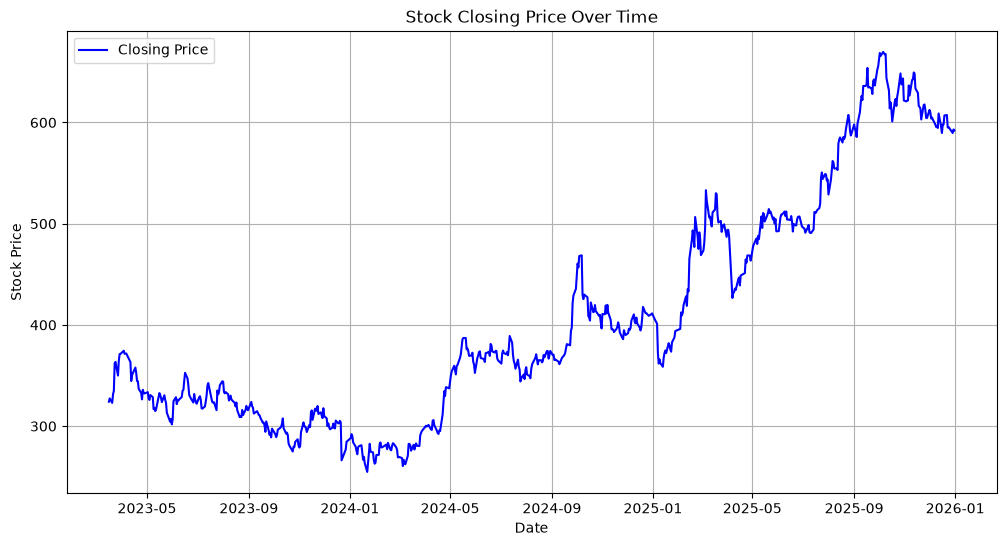

In [19]:
# EDA to explore trends and patterns

plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Closing Price Over Time")  
plt.plot(df['Close'], label="Closing Price", color="blue")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()

7-day MA captures short-term fluctuations while the 50-day MA provides a smoother long-term trend

Sharp deviations between moving averages may indicate trend reversals

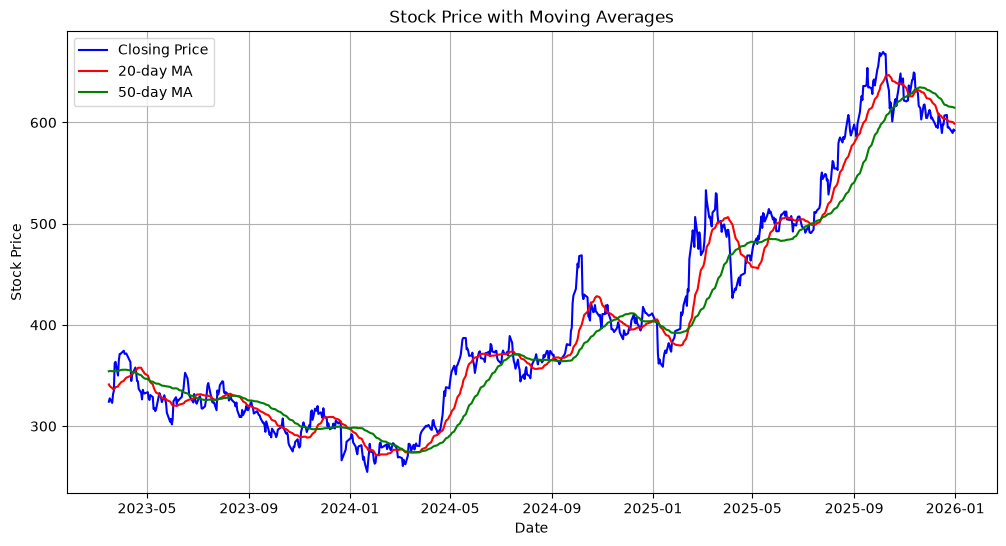

In [20]:
# To smoothen short-term fluctuations with moving averages

plt.figure(figsize=(12,6))
plt.xlabel("Date")  
plt.ylabel("Stock Price")  
plt.title("Stock Price with Moving Averages")
plt.plot(df['Close'], label="Closing Price", color="blue")
plt.plot(df['20-day MA'], label="20-day MA", color="red")
plt.plot(df['50-day MA'], label="50-day MA", color="green")
#plt.plot(df['Date'], df['Close'], label="Closing Price", color="blue")  
plt.grid(True)
plt.legend()  
plt.show()


20-day MA captures short-term fluctuations while the 50-day MA provides smoother medium-term trend

Sharp deviations between moving averages may indicate trend reversals

Large spikes indicate high volatility days

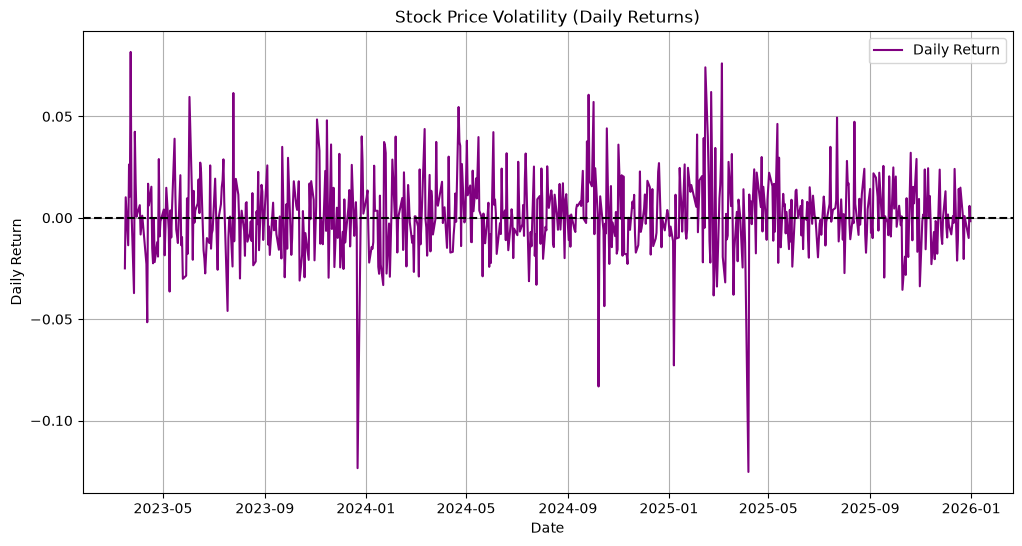

In [21]:
# To analyse Volatility

plt.figure(figsize=(12, 6))
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.title("Stock Price Volatility (Daily Returns)")
plt.plot(df['Daily Return'], label="Daily Return", color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

In [22]:
# To check basic statistical details
df.describe()

,Close,High,Low,Open,Volume,20-day MA,50-day MA,Daily Return
count,686.000000,686.000000,686.000000,686.000000,6.860000e+02,686.000000,686.000000,686.000000
mean,407.206988,412.446017,402.177955,407.471655,2.183908e+07,403.620222,398.102355,0.001044
std,111.235586,112.097010,110.319190,111.511836,1.403414e+07,108.229462,102.289141,0.020099
min,254.736938,263.869378,252.793865,258.428775,0.000000e+00,271.126753,274.074400,-0.125352
25%,318.036499,323.521736,315.475290,320.412797,1.430707e+07,320.766640,324.031794,-0.010690
50%,371.592453,375.410841,367.942606,370.522176,1.827510e+07,369.728510,365.484158,0.000000
75%,494.982986,500.233496,489.357245,494.864212,2.471760e+07,490.779268,479.663534,0.011279
max,669.697388,675.134065,662.283778,672.168613,1.470149e+08,646.888147,634.774288,0.081797


In [23]:
# For normailized Data

# from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))  
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [24]:
# ADF Test : p-value < 0.05 for stationary data

#from statsmodels.tsa.stattools import adfuller

close_series = df['Close']
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -0.3929620951383837
p-value: 0.9112672402985778
The series is not stationary.


??? Where to place...

Stock prices fluctuate due to various factors: company earnings, economic trends, geopolitical events, and market sentiment. While no model can predict prices with 100% accuracy, deep learning techniques like LSTMs may discover trends and patterns in historical data.

Traditional models like ARIMA and Exponential Smoothing work well for linear time series, but struggle with the long-term dependencies in stock market data. LSTMs overcome these limitations by learning long-term relationships for financial forecasting.

# To transform time series stationary...
There are three major time series patterns: trend, seasonality, and cycles. Trend and cycles are usually combined into a single component, with a trend-cycle component, a seasonal component, and a remainder component (containing the rest of the time series).

To make time series stationary, the principle is to estimate trend and seasonality, and to remove those from the time series. Then to apply the forecasting technique (i.e here LSTM), the final step being to convert the forcasted values into the original scale by adding the estimated trend and seasonality.

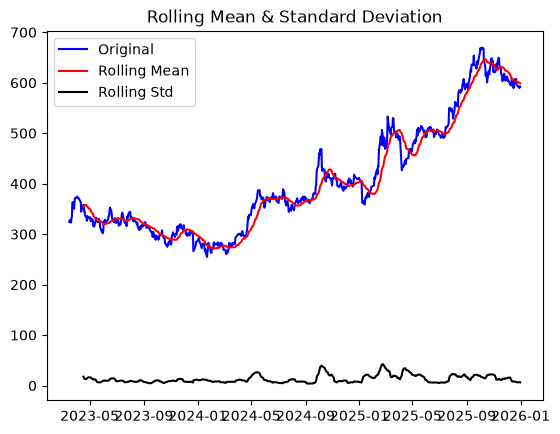

Results of Dickey-Fuller Test:
Test Statistic                  -0.392962
p-value                          0.911267
#Lags Used                       0.000000
Number of Observations Used    685.000000
Critical Value (1%)             -3.439932
Critical Value (5%)             -2.865769
Critical Value (10%)            -2.569022
dtype: float64


In [40]:
#... The following cells are use for model(s), such as LSTM in transformation
#... test stationarity with DFT

close_series = df['Close']
def test_stationarity(timeseries):
    '''
    Input: timeseries (dataframe): timeseries for which we want to study the stationarity
    '''
    
    #Determing rolling statistics
    rolmean = timeseries.rolling(20).mean()
    rolstd = timeseries.rolling(20).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value',\
                                             '#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

test_stationarity(close_series)

<Figure size 640x480 with 0 Axes>

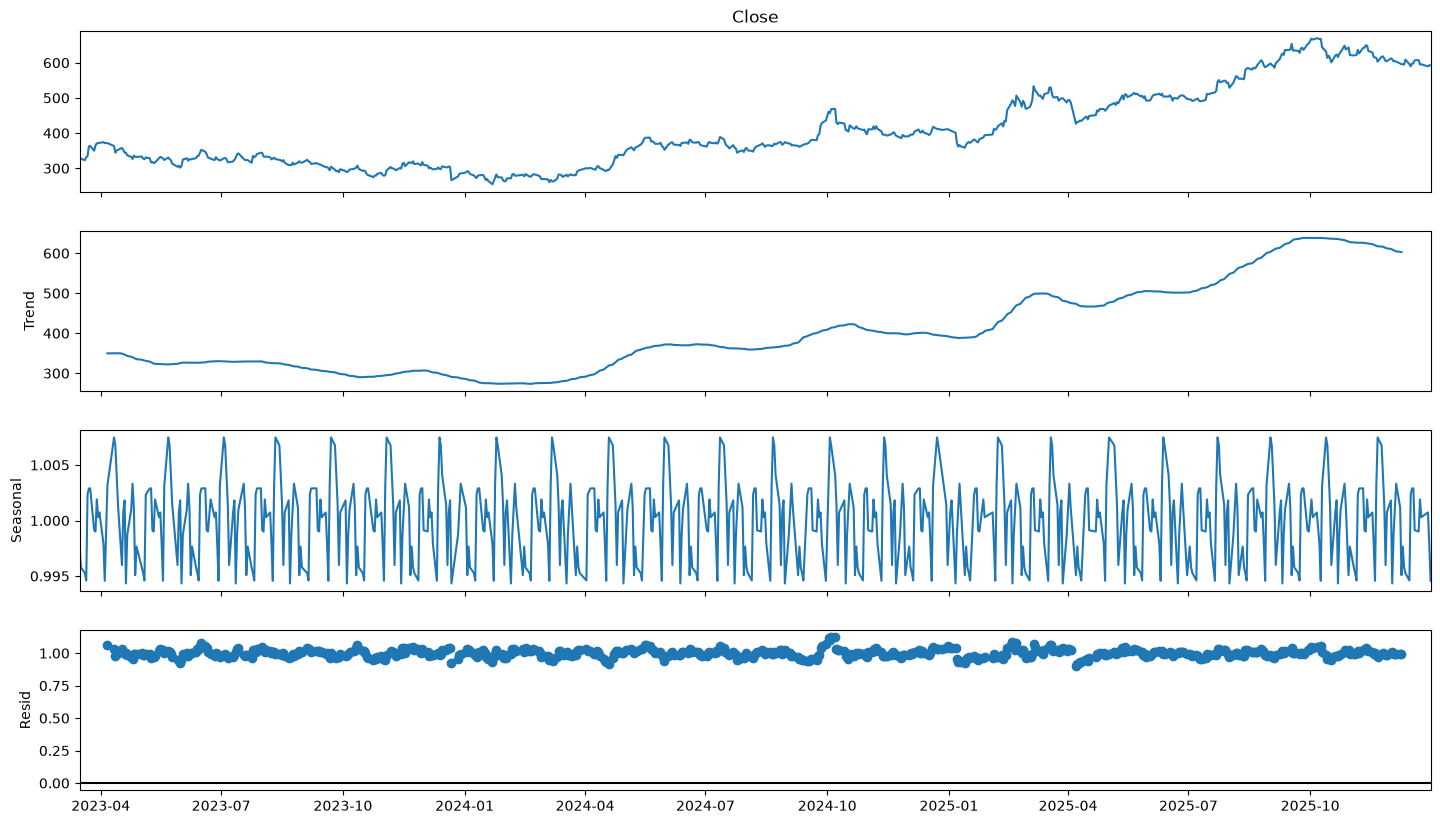

In [41]:
#from statsmodels.tsa.seasonal import seasonal_decompose

#To plot & view the trend and the seasonality
# here set the period to 28 as monthly average 

df_close = df['Close']
result = seasonal_decompose(df_close, model='multiplicative',period=28)
fig = plt.figure()  
fig = result.plot()  
fig.set_size_inches(16, 9)

Text(0.5, 1.0, 'Transformed data')

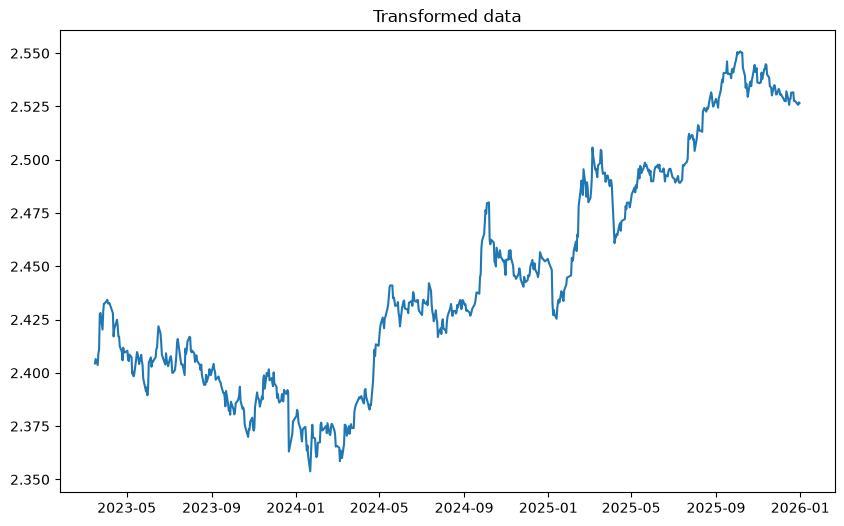

In [42]:
#... To apply log transform to reduce the trends effect while square root transform to flatten 

df_close_log = df_close.apply(np.log)
df_close_tf = df_close_log.apply(np.sqrt)

plt.figure(figsize = (10,6))
plt.plot(df_close_tf)
plt.title('Transformed data')

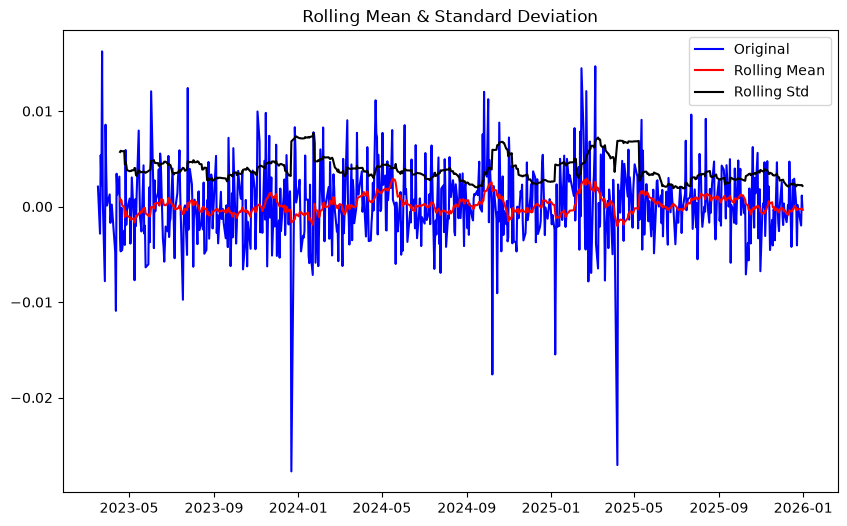

Results of Dickey-Fuller Test:
Test Statistic                 -26.070307
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    684.000000
Critical Value (1%)             -3.439947
Critical Value (5%)             -2.865775
Critical Value (10%)            -2.569025
dtype: float64


In [43]:
#... classical methold differenciating to handel with trand and seasonality
df_close_shift = df_close_tf - df_close_tf.shift()

df_close_shift.dropna(inplace=True)
plt.figure(figsize = (10,6))
test_stationarity(df_close_shift)

check p-value

For this study, we will focus on the closing price, as it represents the final market sentiment for each trading day.

In [77]:
# Prepare for initial set of data for analysis

#import yfinance as yf
hkstock = yf.download('0700.HK', start='2025-09-01', end='2026-09-01', 
                      auto_adjust=True, progress=False).droplevel('Ticker', axis=1)

hkstock['Close']

Date
2025-09-01    598.032349
2025-09-02    593.584167
2025-09-03    591.607239
2025-09-04    585.676331
2025-09-05    598.526611
                 ...    
2026-08-25    442.000000
2026-08-26    445.399994
2026-08-27    447.799988
2026-08-28    455.200012
2026-08-31    453.000000
Name: Close, Length: 245, dtype: float64

#... To export initial data sets

In [79]:
hkstock = yf.download('0005.HK', start='2023-01-01', end='2026-01-01', 
                      auto_adjust=True, progress=False).droplevel('Ticker', axis=1)
close_prices = hkstock['Close']

# Save to CSV
close_prices.to_csv('0005.HK260101.csv')

In [80]:
hkstock = yf.download('0005.HK', start='2023-07-01', end='2026-07-01', 
                      auto_adjust=True, progress=False).droplevel('Ticker', axis=1)
close_prices = hkstock['Close']

# Save to CSV
close_prices.to_csv('0005.HK260701.csv')

In [81]:
hkstock = yf.download('^hsi', start='2023-01-01', end='2026-01-01', 
                      auto_adjust=True, progress=False).droplevel('Ticker', axis=1)
close_prices = hkstock['Close']

# Save to CSV
close_prices.to_csv('^hsi260101.csv')

In [85]:
hkstock = yf.download('^hsi', start='2023-07-01', end='2026-07-01', 
                      auto_adjust=True, progress=False).droplevel('Ticker', axis=1)
close_prices = hkstock['Close']

# Save to CSV
close_prices.to_csv('^hsi260701.csv')

In [83]:
hkstock = yf.download('0700.HK', start='2023-01-01', end='2026-01-01', 
                      auto_adjust=True, progress=False).droplevel('Ticker', axis=1)
close_prices = hkstock['Close']

# Save to CSV
close_prices.to_csv('0700.HK260101.csv')

In [84]:
hkstock = yf.download('0700.HK', start='2023-07-01', end='2026-07-01', 
                      auto_adjust=True, progress=False).droplevel('Ticker', axis=1)
close_prices = hkstock['Close']

# Save to CSV
close_prices.to_csv('0700.HK260701.csv')

...